# Supervised baseline: train on the *labelled* splits, ignore `train_unlabeled`

A second, independent approach — nothing here shares state with the silver-label
pipeline in `word_classifier_final_copy.ipynb`.

**The idea.** `train_unlabeled` has no labels, which is why the other notebook
spends API quota manufacturing silver ones. Several Mu-SHROOM teams skipped that
entirely: they threw away the unlabelled training split and treated the *labelled*
`validation` split as their training data, splitting it into a train and a test
portion, fine-tuning a token classifier on the train portion and evaluating on
what was held out.

**What this notebook does.**

1. loads only `validation` (499 rows) and `test` (1,902 rows) — `train_unlabeled`
   is never touched;
2. splits `validation` 80/20, stratified by language;
3. fine-tunes a token classifier on the 80%;
4. evaluates on the held-out 20% **and** on the full official `test` split, with
   the official metrics (IoU, ρ) plus supplementary character-level F-β.

**Why this is worth having.** It is supervised on real human annotations rather
than on LLM votes, so it is the honest upper reference for the silver-label
approach — and the comparison between the two is the interesting result, not
either number alone.

**The catch, stated up front.** 399 training rows is very little, and the gold
`validation` split is the same data everyone else uses for model selection. Two
consequences worth being explicit about in the report:

- the held-out 20% (100 rows) is small enough that its scores are noisy;
- `test` is the only clean number here, and only as long as nothing is tuned on it.

**Invariant:** the answer text is never normalised. Every gold offset indexes the
raw string, so changing its length would invalidate all of them.

In [1]:
import os

import numpy as np
import torch
from datasets import load_dataset
from scipy.stats import spearmanr
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)

# ---- configuration ---------------------------------------------------------

# here; "xlm-roberta-base" is a one-line swap and the rest of the code is

MODEL_NAME = "xlm-roberta-large"

MAX_LENGTH = 512
EVAL_FRACTION = 0.2
SEED = 42

# Official binarisation rule: a character counts as hallucinated when its
# probability is strictly greater than 0.5.
OFFICIAL_CUTOFF = 0.5

# New output paths: nothing here overwrites artefacts from the other notebook.
OUTPUT_DIR = "./val-trained-detector-large"
FINAL_MODEL_DIR = "./val_trained_detector_large"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))

torch 2.11.0+cu128 | device: cuda
NVIDIA GeForce RTX 5070 Laptop GPU


### 1. Load the labelled splits

`train_unlabeled` is deliberately not loaded.

In [2]:
dataset = load_dataset("Helsinki-NLP/mu-shroom", "all")

val = dataset["validation"]
test = dataset["test"]

print(f"validation: {len(val)} rows")
print(f"test:       {len(test)} rows")
print("validation languages:", sorted(set(val["lang"])))
print("test languages:      ", sorted(set(test["lang"])))
print("\nno-hallucination rows | validation:",
      sum(1 for h in val["hard_labels"] if not h),
      "| test:", sum(1 for h in test["hard_labels"] if not h))

validation: 499 rows
test:       1902 rows
validation languages: ['AR', 'DE', 'EN', 'ES', 'FI', 'FR', 'HI', 'IT', 'SV', 'ZH']
test languages:       ['AR', 'CA', 'CS', 'DE', 'EN', 'ES', 'EU', 'FA', 'FI', 'FR', 'HI', 'IT', 'SV', 'ZH']

no-hallucination rows | validation: 21 | test: 57


### 2. Gold labels → per-character arrays

`hard_labels` is already the official `prob > 0.5` binarisation of the annotator
votes, so it is used as-is for the training target. `soft_labels` is kept as a
per-character probability vector because it is what the ρ metric compares
against, and what a soft-label loss would need.

In [3]:
def gold_hard_char_labels(row):
    """
    Expand a row's gold `hard_labels` spans into a per-character 0/1 array.

    Args:
        row (dict): a labelled Mu-SHROOM row.

    Returns:
        numpy.ndarray: `int64` array of length `len(model_output_text)`.

    Example:
        >>> row = {"model_output_text": "abcdef", "hard_labels": [[1, 3]]}
        >>> gold_hard_char_labels(row).tolist()
        [0, 1, 1, 0, 0, 0]
    """
    text = row["model_output_text"]
    labels = np.zeros(len(text), dtype=np.int64)

    for start, end in row["hard_labels"]:
        labels[int(start):min(int(end), len(text))] = 1

    return labels


def gold_soft_char_probs(row):
    """
    Expand a row's gold `soft_labels` into a per-character probability vector.

    Args:
        row (dict): a labelled Mu-SHROOM row.

    Returns:
        numpy.ndarray: `float` array of length `len(model_output_text)`.

    Example:
        >>> row = {"model_output_text": "abcd",
        ...        "soft_labels": [{"start": 0, "end": 2, "prob": 0.75}]}
        >>> gold_soft_char_probs(row).tolist()
        [0.75, 0.75, 0.0, 0.0]
    """
    text = row["model_output_text"]
    probs = np.zeros(len(text), dtype=float)

    for span in row["soft_labels"]:
        probs[int(span["start"]):min(int(span["end"]), len(text))] = float(span["prob"])

    return probs


example_row = val[0]
print(example_row["model_output_text"])
print("hard:", gold_hard_char_labels(example_row).tolist())
print("soft:", [round(p, 2) for p in gold_soft_char_probs(example_row).tolist()])

جليقة، التي تعرف الآن باسم كوريا الجنوبية، تتألف من 16 مقاطعة.
hard: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
soft: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.33, 0.33, 0.33, 0.33, 0.33, 0.33, 0.33, 0.0]


### 3. Tokenise and align labels to tokens

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_and_align_labels(example):
    """
    Tokenise one answer and project its gold character labels onto tokens.

    Args:
        example (dict): a labelled row with `model_output_text` and
            `hard_labels`.

    Returns:
        dict: `input_ids`, `attention_mask`, `token_type_ids` and `labels`, one
        entry per real token.

    Example:
        >>> encoded = tokenize_and_align_labels(val[0])
        >>> len(encoded["input_ids"]) == len(encoded["labels"])
        True
        >>> set(encoded["labels"]) <= {-100, 0, 1}
        True
    """
    text = example["model_output_text"]

    char_labels = gold_hard_char_labels(example)

    encoding = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        return_offsets_mapping=True,
    )

    token_labels = []

    for start, end in encoding["offset_mapping"]:

        # special tokens
        if start == end:
            token_labels.append(-100)
            continue

        token_labels.append(1 if char_labels[start:end].any() else 0)

    encoding["labels"] = token_labels

    encoding.pop("offset_mapping")

    return encoding


encoded_example = tokenize_and_align_labels(val[0])
print("tokens:", len(encoded_example["input_ids"]),
      "| labels:", len(encoded_example["labels"]),
      "| positive tokens:", sum(1 for label in encoded_example["labels"] if label == 1))

tokens: 21 | labels: 21 | positive tokens: 4


### 4. Split `validation` into a train and a test portion

Stratified by language so all ten languages appear on both sides — an unstratified
random split of 499 rows can easily leave a language with two or three rows in the
held-out portion and make its per-language score meaningless.

In [5]:
def split_indices_by_language(split, eval_fraction=EVAL_FRACTION, seed=SEED):
    """
    Split row indices into train/eval, keeping the language mix in both.

    Args:
        split (datasets.Dataset): the split to divide, carrying a `lang` column.
        eval_fraction (float): share of rows held out.
        seed (int): random seed.

    Returns:
        tuple[list[int], list[int]]: (train indices, eval indices).

    Example:
        >>> train_idx, eval_idx = split_indices_by_language(val)
        >>> len(train_idx), len(eval_idx)
        (399, 100)
    """
    indices = list(range(len(split)))

    train_indices, eval_indices = train_test_split(
        indices,
        test_size=eval_fraction,
        random_state=seed,
        stratify=split["lang"],
    )

    return sorted(train_indices), sorted(eval_indices)


train_indices, eval_indices = split_indices_by_language(val)

val_train_raw = val.select(train_indices)
val_eval_raw = val.select(eval_indices)

print(f"train portion: {len(val_train_raw)} rows")
print(f"held-out portion: {len(val_eval_raw)} rows")

import collections
print("held-out language mix:", dict(sorted(collections.Counter(val_eval_raw["lang"]).items())))

train_dataset = val_train_raw.map(
    tokenize_and_align_labels,
    remove_columns=val_train_raw.column_names,
)

eval_dataset = val_eval_raw.map(
    tokenize_and_align_labels,
    remove_columns=val_eval_raw.column_names,
)

label_values = [label for row in train_dataset["labels"] for label in row if label != -100]
print(f"\ntoken class balance in the training portion: "
      f"{np.mean(label_values):.4f} positive "
      f"({sum(label_values)} / {len(label_values)} tokens)")

train portion: 399 rows
held-out portion: 100 rows
held-out language mix: {'AR': 10, 'DE': 10, 'EN': 10, 'ES': 10, 'FI': 10, 'FR': 10, 'HI': 10, 'IT': 10, 'SV': 10, 'ZH': 10}

token class balance in the training portion: 0.3959 positive (12681 / 32033 tokens)


### 5. Fine-tune the token classifier

In [6]:
def compute_metrics(eval_pred):
    """
    Positive-class precision / recall / F1 for token classification.
    """
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    mask = labels != -100
    y_true = labels[mask]
    y_pred = predictions[mask]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predicted_positive_rate": float(y_pred.mean()),
    }


model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    # eval_loss would rank a do-nothing model highly on this class balance
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    fp16=(DEVICE == "cuda"),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()

trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

d:\Uni_material\sem-2\3) 31_July_Deep_learning_NLP\VeriLLM\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--xlm-roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./val_trained_detector_large\\tokenizer_config.json',
 './val_trained_detector_large\\tokenizer.json')

### 6. Training and evaluation loss curves

saved val_trained_loss_curves.png


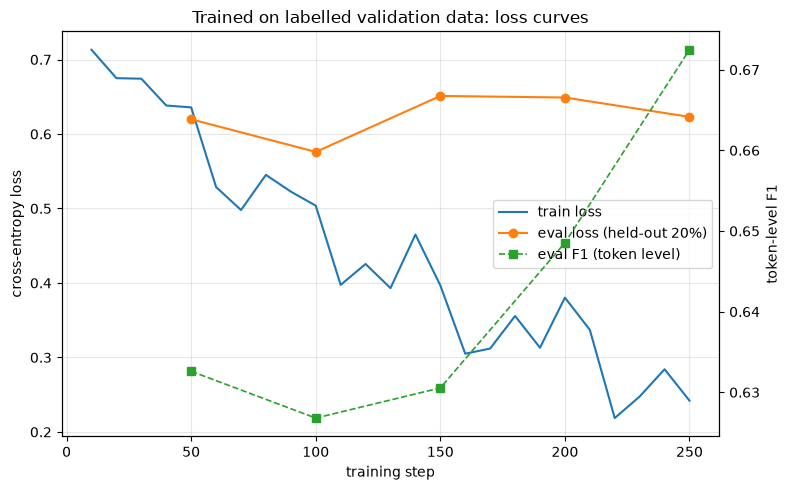

In [7]:
def get_loss_history(trainer):
    """
    Pull the training and evaluation loss curves out of a finished Trainer.

    `trainer.state.log_history` interleaves optimizer logs carrying `loss` with
    evaluation logs carrying `eval_loss`; this separates them into two series on
    a shared step axis.

    Args:
        trainer (transformers.Trainer): a Trainer whose `train()` has run.

    Returns:
        dict: `{"train": [(step, loss), ...], "eval": [(step, loss), ...],
        "eval_f1": [(step, f1), ...]}`.

    Example:
        >>> history = get_loss_history(trainer)
        >>> len(history["eval"])
        5
    """
    log_history = trainer.state.log_history

    return {
        "train": [
            (entry["step"], entry["loss"])
            for entry in log_history
            if "loss" in entry and "eval_loss" not in entry
        ],
        "eval": [
            (entry["step"], entry["eval_loss"])
            for entry in log_history
            if "eval_loss" in entry
        ],
        "eval_f1": [
            (entry["step"], entry["eval_f1"])
            for entry in log_history
            if "eval_f1" in entry
        ],
    }


def plot_loss_curves(trainer, save_path="val_trained_loss_curves.png"):
    """
    Plot training loss against held-out loss, with F1 on a second axis.

    The gap between the two loss curves is the thing to read: with only ~399
    training rows, train falling while eval flattens or rises is the expected
    failure mode, and the F1 curve says whether the model is still learning
    anything useful while that happens.

    Falls back to printing the same numbers when matplotlib is unavailable, so
    the cell never breaks the run.

    Args:
        trainer (transformers.Trainer): a Trainer whose `train()` has run.
        save_path (str | None): PNG destination, or None to skip saving.

    Returns:
        dict: the history from `get_loss_history`.

    Example:
        >>> history = plot_loss_curves(trainer)
        saved val_trained_loss_curves.png
        >>> len(history["train"]) > 0
        True
    """
    history = get_loss_history(trainer)

    if not history["train"] and not history["eval"]:
        print("No loss logged - has trainer.train() been run in this session?")
        return history

    try:
        import matplotlib.pyplot as plt
    except ImportError:
        plt = None

    if plt is None:
        print("matplotlib is not installed - run `pip install matplotlib` for the plot.")
        print(f"{'step':>8} {'train_loss':>12} {'eval_loss':>12} {'eval_f1':>10}")

        eval_f1 = dict(history["eval_f1"])

        for step, loss in history["train"]:
            print(f"{step:>8} {loss:>12.4f} {'':>12} {'':>10}")

        for step, loss in history["eval"]:
            print(f"{step:>8} {'':>12} {loss:>12.4f} {eval_f1.get(step, float('nan')):>10.4f}")

        return history

    figure, axis = plt.subplots(figsize=(8, 5))

    if history["train"]:
        axis.plot(
            [step for step, _ in history["train"]],
            [loss for _, loss in history["train"]],
            label="train loss",
            linewidth=1.5,
        )

    if history["eval"]:
        axis.plot(
            [step for step, _ in history["eval"]],
            [loss for _, loss in history["eval"]],
            label="eval loss (held-out 20%)",
            linewidth=1.5,
            marker="o",
        )

    axis.set_xlabel("training step")
    axis.set_ylabel("cross-entropy loss")
    axis.set_title("Trained on labelled validation data: loss curves")
    axis.grid(alpha=0.3)

    if history["eval_f1"]:
        f1_axis = axis.twinx()
        f1_axis.plot(
            [step for step, _ in history["eval_f1"]],
            [value for _, value in history["eval_f1"]],
            label="eval F1 (token level)",
            linewidth=1.2,
            linestyle="--",
            marker="s",
            color="tab:green",
        )
        f1_axis.set_ylabel("token-level F1")

        lines, labels = axis.get_legend_handles_labels()
        f1_lines, f1_labels = f1_axis.get_legend_handles_labels()
        axis.legend(lines + f1_lines, labels + f1_labels, loc="center right")
    else:
        axis.legend()

    figure.tight_layout()

    if save_path:
        figure.savefig(save_path, dpi=150)
        print(f"saved {save_path}")

    plt.show()

    return history


loss_history = plot_loss_curves(trainer)

### 7. Official scorer

Reimplemented from the shared task's `participant_kit/scorer.py`: character-level
IoU as the primary metric, Spearman ρ as the tie-breaker, with the empty-item and
constant-vector special cases carried over verbatim. Character-level precision /
recall / F-β is added on top — not official, but it distinguishes over-marking
from under-marking, which IoU alone cannot.

In [8]:
def char_probs_to_hard_labels(char_probs, cutoff=OFFICIAL_CUTOFF):
    """
    Binarise a per-character probability vector into official `[start, end]` spans.

    Args:
        char_probs (Sequence[float]): one probability per character.
        cutoff (float): threshold; the comparison is strictly greater-than, as
            in the official scorer.

    Returns:
        list[list[int]]: half-open spans, possibly empty.

    Example:
        >>> char_probs_to_hard_labels([0.1, 0.9, 0.8, 0.2, 0.7])
        [[1, 3], [4, 5]]
    """
    spans = []
    start = None

    for index, prob in enumerate(char_probs):

        if prob > cutoff and start is None:
            start = index

        elif prob <= cutoff and start is not None:
            spans.append([start, index])
            start = None

    if start is not None:
        spans.append([start, len(char_probs)])

    return spans


def char_probs_to_soft_labels(char_probs):
    """
    Run-length encode a probability vector into official `soft_labels` segments.

    Only non-zero runs are emitted; the scorer initialises its vectors to zero
    and fills in what it is given, so the result is equivalent and smaller.

    Args:
        char_probs (Sequence[float]): one probability per character.

    Returns:
        list[dict]: `{"start", "end", "prob"}` segments.

    Example:
        >>> char_probs_to_soft_labels([0.0, 0.5, 0.5, 0.0, 1.0])
        [{'start': 1, 'end': 3, 'prob': 0.5}, {'start': 4, 'end': 5, 'prob': 1.0}]
    """
    labels = []
    length = len(char_probs)
    start = 0

    for index in range(1, length + 1):

        if index == length or char_probs[index] != char_probs[start]:

            prob = float(char_probs[start])

            if prob > 0.0:
                labels.append({"start": start, "end": index, "prob": prob})

            start = index

    return labels


def score_iou(ref_dict, pred_dict):
    """
    Official character-level IoU for one datapoint.

    Args:
        ref_dict (dict): gold record with `id` and `hard_labels`.
        pred_dict (dict): prediction with the same `id` and `hard_labels`.

    Returns:
        float: IoU in [0, 1]; 1.0 when gold and prediction are both empty, which
        is the rule that makes the 21 clean validation rows scoreable at all.

    Example:
        >>> score_iou({"id": "x", "hard_labels": [[0, 5]]},
        ...           {"id": "x", "hard_labels": [[3, 8]]})
        0.25
    """
    assert ref_dict["id"] == pred_dict["id"]

    ref_indices = {idx for span in ref_dict["hard_labels"] for idx in range(*span)}
    pred_indices = {idx for span in pred_dict["hard_labels"] for idx in range(*span)}

    if not pred_indices and not ref_indices:
        return 1.0

    return len(ref_indices & pred_indices) / len(ref_indices | pred_indices)


def score_cor(ref_dict, pred_dict):
    """
    Official Spearman correlation between gold and predicted soft labels.

    Both sides become dense vectors of length `ref_dict["text_len"]`. A constant
    vector has no variance, so ρ is undefined; the official rule returns 1.0
    when both vectors are constant and 0.0 otherwise, reproduced here including
    the 8-decimal rounding used to decide constancy.

    Args:
        ref_dict (dict): gold record with `id`, `text_len` and `soft_labels`.
        pred_dict (dict): prediction with the same `id` and `soft_labels`.

    Returns:
        float: Spearman ρ, or the 0.0 / 1.0 constant-vector fallback.

    Example:
        >>> score_cor({"id": "x", "text_len": 4,
        ...            "soft_labels": [{"start": 0, "end": 2, "prob": 1.0}]},
        ...           {"id": "x",
        ...            "soft_labels": [{"start": 0, "end": 2, "prob": 0.8}]})
        1.0
    """
    assert ref_dict["id"] == pred_dict["id"]

    ref_vec = [0.0] * ref_dict["text_len"]
    pred_vec = [0.0] * ref_dict["text_len"]

    for span in ref_dict["soft_labels"]:
        for idx in range(span["start"], span["end"]):
            ref_vec[idx] = span["prob"]

    for span in pred_dict["soft_labels"]:
        for idx in range(span["start"], span["end"]):
            pred_vec[idx] = span["prob"]

    if len({round(flt, 8) for flt in pred_vec}) == 1 or len({round(flt, 8) for flt in ref_vec}) == 1:
        return float(
            len({round(flt, 8) for flt in ref_vec}) == len({round(flt, 8) for flt in pred_vec})
        )

    return spearmanr(ref_vec, pred_vec).correlation


def score_fbeta(ref_dict, pred_dict, beta=1.0):
    """
    Character-level precision, recall and F-β for one datapoint.

    Supplementary, not official. `beta > 1` weights recall more heavily, which
    is the usual choice when missing a hallucination is worse than over-flagging
    one.

    Args:
        ref_dict (dict): gold record with `id` and `hard_labels`.
        pred_dict (dict): prediction with the same `id` and `hard_labels`.
        beta (float): recall weight.

    Returns:
        tuple[float, float, float]: (precision, recall, f_beta); all 1.0 when
        both sides are empty, all 0.0 when exactly one is.

    Example:
        >>> [round(v, 3) for v in score_fbeta({"id": "x", "hard_labels": [[0, 10]]},
        ...                                   {"id": "x", "hard_labels": [[0, 5]]},
        ...                                   beta=2.0)]
        [1.0, 0.5, 0.556]
    """
    assert ref_dict["id"] == pred_dict["id"]

    ref_indices = {idx for span in ref_dict["hard_labels"] for idx in range(*span)}
    pred_indices = {idx for span in pred_dict["hard_labels"] for idx in range(*span)}

    if not ref_indices and not pred_indices:
        return 1.0, 1.0, 1.0

    if not ref_indices or not pred_indices:
        return 0.0, 0.0, 0.0

    true_positive = len(ref_indices & pred_indices)

    precision = true_positive / len(pred_indices)
    recall = true_positive / len(ref_indices)

    if precision + recall == 0.0:
        return precision, recall, 0.0

    beta_squared = beta ** 2

    f_beta = (
        (1 + beta_squared) * precision * recall
        / (beta_squared * precision + recall)
    )

    return precision, recall, f_beta

### 8. Predictions and reporting

In [9]:
def build_reference_records(split):
    """
    Convert a labelled split into scorer records, reading the text raw.

    Args:
        split (datasets.Dataset): `validation`, `test`, or a selection of one.

    Returns:
        list[dict]: records with `id`, `lang`, `text`, `text_len`,
        `hard_labels` and `soft_labels`.

    Example:
        >>> refs = build_reference_records(val)
        >>> refs[0]["id"], refs[0]["text_len"]
        ('val-ar-1', 62)
    """
    records = []

    for row in split:

        text = row["model_output_text"]

        records.append({
            "id": row["id"],
            "lang": row["lang"],
            "text": text,
            "text_len": len(text),
            "hard_labels": [[int(start), int(end)] for start, end in row["hard_labels"]],
            "soft_labels": [
                {
                    "start": int(span["start"]),
                    "end": int(span["end"]),
                    "prob": float(span["prob"]),
                }
                for span in row["soft_labels"]
            ],
        })

    return records


def predict_char_probs(texts, model, tokenizer, device=DEVICE, batch_size=16, max_length=MAX_LENGTH):
    """
    Run the classifier and project token probabilities back onto characters.

    The offset mapping says which characters each token covers, so the token's
    class-1 probability is written across that range; overlapping sub-word
    pieces keep the maximum. Characters past the truncation point stay at 0.0 —
    the model has no opinion there, and pretending otherwise would inflate
    recall on long answers.

    Args:
        texts (list[str]): raw answer texts, in reference order.
        model: a loaded `AutoModelForTokenClassification`.
        tokenizer: the matching fast tokenizer.
        device (str): "cuda" or "cpu".
        batch_size (int): rows per forward pass.
        max_length (int): token truncation length.

    Returns:
        list[numpy.ndarray]: one probability vector per text, `len(text)` long.

    Example:
        >>> probs = predict_char_probs([r["text"] for r in eval_refs], model, tokenizer)
        >>> probs[0].shape[0] == eval_refs[0]["text_len"]
        True
    """
    model.to(device)
    model.eval()

    all_char_probs = []

    for batch_start in range(0, len(texts), batch_size):

        chunk = texts[batch_start:batch_start + batch_size]

        encoding = tokenizer(
            chunk,
            truncation=True,
            max_length=max_length,
            padding=True,
            return_offsets_mapping=True,
            return_tensors="pt",
        )

        offset_mapping = encoding.pop("offset_mapping")
        attention_mask = encoding["attention_mask"]

        inputs = {key: value.to(device) for key, value in encoding.items()}

        with torch.no_grad():
            logits = model(**inputs).logits

        token_probs = torch.softmax(logits, dim=-1)[:, :, 1].cpu().numpy()

        for row_index, text in enumerate(chunk):

            char_probs = np.zeros(len(text), dtype=float)

            offsets = offset_mapping[row_index].tolist()
            mask = attention_mask[row_index].tolist()

            for (start, end), prob, is_real in zip(offsets, token_probs[row_index], mask):

                if not is_real or start == end:
                    continue

                char_probs[start:end] = np.maximum(char_probs[start:end], prob)

            all_char_probs.append(char_probs)

    return all_char_probs


def build_prediction_records(references, all_char_probs, cutoff=OFFICIAL_CUTOFF):
    """
    Package probability vectors into scorer-format prediction records.

    Both label kinds come from the same vector, which is what keeps IoU and ρ
    comparable to each other.

    Args:
        references (list[dict]): reference records, used for their ids.
        all_char_probs (list[numpy.ndarray]): probabilities in the same order.
        cutoff (float): binarisation threshold for the hard labels.

    Returns:
        list[dict]: `{"id", "lang", "hard_labels", "soft_labels"}` records.

    Example:
        >>> preds = build_prediction_records(eval_refs, eval_probs)
        >>> preds[0]["id"] == eval_refs[0]["id"]
        True
    """
    predictions = []

    for reference, char_probs in zip(references, all_char_probs):

        predictions.append({
            "id": reference["id"],
            "lang": reference["lang"],
            "hard_labels": char_probs_to_hard_labels(char_probs, cutoff=cutoff),
            "soft_labels": char_probs_to_soft_labels(char_probs),
        })

    return predictions


def baseline_mark_none(references):
    """
    Baseline that predicts no hallucination anywhere.

    Its IoU is exactly the fraction of items whose gold is also empty, so it is
    the floor any real system has to clear.

    Args:
        references (list[dict]): reference records.

    Returns:
        list[dict]: prediction records with empty label lists.

    Example:
        >>> round(evaluate(val_refs, baseline_mark_none(val_refs))["IoU"], 4)
        0.0421
    """
    return [
        {"id": r["id"], "lang": r["lang"], "hard_labels": [], "soft_labels": []}
        for r in references
    ]


def baseline_mark_all(references):
    """
    Baseline that marks the whole answer as hallucinated.

    Per item this scores `len(gold) / len(text)`, and 0.0 on every clean item.
    On the full validation split it reaches IoU 0.3577 — a surprisingly high bar,
    because most answers in this data are largely wrong.

    Args:
        references (list[dict]): reference records.

    Returns:
        list[dict]: prediction records covering the whole text at prob 1.0.

    Example:
        >>> round(evaluate(val_refs, baseline_mark_all(val_refs))["IoU"], 4)
        0.3577
    """
    predictions = []

    for reference in references:

        text_len = reference["text_len"]

        predictions.append({
            "id": reference["id"],
            "lang": reference["lang"],
            "hard_labels": [[0, text_len]] if text_len else [],
            "soft_labels": [{"start": 0, "end": text_len, "prob": 1.0}] if text_len else [],
        })

    return predictions


def evaluate(references, predictions, betas=(1.0, 2.0)):
    """
    Average the official metrics, plus F-β, over a set of datapoints.

    Predictions are matched to references by `id`, not position.

    Args:
        references (list[dict]): gold records.
        predictions (list[dict]): prediction records.
        betas (tuple[float]): which F-β variants to report.

    Returns:
        dict: `n`, `IoU`, `rho`, `precision`, `recall`, and one `F<beta>` key
        per requested beta.

    Example:
        >>> scores = evaluate(val_refs, baseline_mark_all(val_refs))
        >>> scores["n"], round(scores["IoU"], 4), round(scores["rho"], 4)
        (499, 0.3577, 0.006)
    """
    predictions_by_id = {p["id"]: p for p in predictions}

    ious = []
    cors = []
    precisions = []
    recalls = []
    fbetas = {beta: [] for beta in betas}

    for reference in references:

        prediction = predictions_by_id[reference["id"]]

        ious.append(score_iou(reference, prediction))
        cors.append(score_cor(reference, prediction))

        precision, recall, _ = score_fbeta(reference, prediction, beta=1.0)
        precisions.append(precision)
        recalls.append(recall)

        for beta in betas:
            fbetas[beta].append(score_fbeta(reference, prediction, beta=beta)[2])

    scores = {
        "n": len(references),
        "IoU": float(np.mean(ious)),
        "rho": float(np.mean(cors)),
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
    }

    for beta in betas:
        scores[f"F{beta:g}"] = float(np.mean(fbetas[beta]))

    return scores


def evaluate_by_language(references, predictions, betas=(1.0, 2.0)):
    """
    Run `evaluate` separately per language.

    Worth doing because the scores spread enormously across languages, and
    because four test languages (CA, CS, EU, FA) appear in no training data at
    all — including the validation rows this notebook trains on.

    Args:
        references (list[dict]): gold records.
        predictions (list[dict]): prediction records.
        betas (tuple[float]): which F-β variants to report.

    Returns:
        dict: `{lang: scores}`, sorted by language code.

    Example:
        >>> by_lang = evaluate_by_language(val_refs, baseline_mark_all(val_refs))
        >>> round(by_lang["ES"]["IoU"], 4), round(by_lang["SV"]["IoU"], 4)
        (0.1389, 0.5329)
    """
    predictions_by_id = {p["id"]: p for p in predictions}

    results = {}

    for language in sorted({r["lang"] for r in references}):

        language_refs = [r for r in references if r["lang"] == language]
        language_preds = [predictions_by_id[r["id"]] for r in language_refs]

        results[language] = evaluate(language_refs, language_preds, betas=betas)

    return results


def print_scores(title, scores):
    """
    Print one metric dictionary as a single aligned line.

    Args:
        title (str): row label.
        scores (dict): output of `evaluate`.

    Returns:
        None

    Example:
        >>> print_scores("validation | mark-all",
        ...              evaluate(val_refs, baseline_mark_all(val_refs)))
        validation | mark-all              n=  499  IoU=0.3577 rho=0.0060 precision=0.3577 recall=0.9579 F1=0.4680 F2=0.6148
    """
    metrics = " ".join(f"{key}={scores[key]:.4f}" for key in scores if key != "n")

    print(f"{title:<38} n={scores['n']:>5}  {metrics}")


def print_language_table(results_by_language):
    """
    Print a per-language score table.

    Args:
        results_by_language (dict): output of `evaluate_by_language`.

    Returns:
        None

    Example:
        >>> print_language_table(evaluate_by_language(val_refs, baseline_mark_all(val_refs)))
        lang       n         IoU         rho   precision      recall          F1          F2
        ------------------------------------------------------------------------------------
        AR        50      0.3354      0.0000      0.3354      1.0000      0.4662      0.6442
        DE        50      0.3938      0.0200      0.3938      0.9200      0.4951      0.6244
        ...
    """
    if not results_by_language:
        print("(no languages to report)")
        return

    metric_names = [key for key in next(iter(results_by_language.values())) if key != "n"]

    header = f"{'lang':<6}{'n':>6}" + "".join(f"{name:>12}" for name in metric_names)
    print(header)
    print("-" * len(header))

    for language, scores in results_by_language.items():
        print(
            f"{language:<6}{scores['n']:>6}"
            + "".join(f"{scores[name]:>12.4f}" for name in metric_names)
        )

### 9. Results on the held-out portion of `validation`

100 rows, so read these as indicative rather than precise — but they are the
numbers the model was selected against, which makes them the optimistic end of
the range.

In [10]:
eval_refs = build_reference_records(val_eval_raw)

eval_probs = predict_char_probs([r["text"] for r in eval_refs], model, tokenizer)
eval_preds = build_prediction_records(eval_refs, eval_probs)

print_scores("held-out val | mark-none", evaluate(eval_refs, baseline_mark_none(eval_refs)))
print_scores("held-out val | mark-all", evaluate(eval_refs, baseline_mark_all(eval_refs)))
print_scores("held-out val | trained on val", evaluate(eval_refs, eval_preds))

print()
print("per language (held-out validation portion)")
print_language_table(evaluate_by_language(eval_refs, eval_preds))

held-out val | mark-none               n=  100  IoU=0.0400 rho=0.0100 precision=0.0400 recall=0.0400 F1=0.0400 F2=0.0400
held-out val | mark-all                n=  100  IoU=0.4064 rho=0.0100 precision=0.4064 recall=0.9600 F1=0.5178 F2=0.6590
held-out val | trained on val          n=  100  IoU=0.4950 rho=0.4761 precision=0.6900 recall=0.6640 F1=0.6098 F2=0.6162

per language (held-out validation portion)
lang       n         IoU         rho   precision      recall          F1          F2
------------------------------------------------------------------------------------
AR        10      0.3755      0.5937      0.6196      0.4921      0.4924      0.4730
DE        10      0.5219      0.5062      0.8208      0.5564      0.6489      0.5885
EN        10      0.5923      0.4671      0.6913      0.7970      0.6741      0.7007
ES        10      0.3960      0.3708      0.5973      0.5247      0.4678      0.4597
FI        10      0.4168      0.4794      0.6489      0.5852      0.5364      0.557

### 10. Results on the full official `test` split

1,902 rows across 14 languages, none of them seen in training. This is the number
to put in the report, and the only one that is not contaminated by model
selection — provided nothing gets tuned against it.

In [11]:
test_refs = build_reference_records(test)

test_probs = predict_char_probs([r["text"] for r in test_refs], model, tokenizer)
test_preds = build_prediction_records(test_refs, test_probs)

print_scores("test | mark-none", evaluate(test_refs, baseline_mark_none(test_refs)))
print_scores("test | mark-all", evaluate(test_refs, baseline_mark_all(test_refs)))
print_scores("test | trained on val", evaluate(test_refs, test_preds))

print()
print("per language (test)")
print_language_table(evaluate_by_language(test_refs, test_preds))

surprise_languages = {"CA", "CS", "EU", "FA"}

preds_by_id = {p["id"]: p for p in test_preds}
surprise_refs = [r for r in test_refs if r["lang"] in surprise_languages]
seen_refs = [r for r in test_refs if r["lang"] not in surprise_languages]

print()
print_scores(
    "test | languages seen in training",
    evaluate(seen_refs, [preds_by_id[r["id"]] for r in seen_refs]),
)
print_scores(
    "test | surprise languages (zero-shot)",
    evaluate(surprise_refs, [preds_by_id[r["id"]] for r in surprise_refs]),
)

test | mark-none                       n= 1902  IoU=0.0300 rho=0.0126 precision=0.0300 recall=0.0300 F1=0.0300 F2=0.0300
test | mark-all                        n= 1902  IoU=0.3521 rho=0.0126 precision=0.3521 recall=0.9700 F1=0.4672 F2=0.6217
test | trained on val                  n= 1902  IoU=0.5037 rho=0.4823 precision=0.6887 recall=0.6566 F1=0.6121 F2=0.6182

per language (test)
lang       n         IoU         rho   precision      recall          F1          F2
------------------------------------------------------------------------------------
AR       150      0.5362      0.5222      0.7584      0.6578      0.6445      0.6354
CA       100      0.4607      0.4645      0.6403      0.5611      0.5458      0.5416
CS       100      0.3862      0.3977      0.4936      0.6490      0.5026      0.5465
DE       150      0.5195      0.4679      0.7192      0.6810      0.6361      0.6388
EN       154      0.4694      0.5259      0.7088      0.5817      0.5776      0.5646
ES       152      0.3

### 11. Threshold sweep — on validation only

The cutoff is the one free parameter left after training. Tune it on the held-out
validation portion if you tune it at all; reading it off `test` would turn the
clean number into another selected one.

In [12]:
def sweep_cutoff(references, all_char_probs, cutoffs=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)):
    """
    Re-score the same probability vectors at several binarisation thresholds.

    Free to run: the model is not re-executed, only the binarisation changes. ρ
    does not depend on the cutoff and stays constant down the table, which is a
    useful sanity check that the sweep is doing what it claims.

    Args:
        references (list[dict]): gold records.
        all_char_probs (list[numpy.ndarray]): probabilities in reference order.
        cutoffs (tuple[float]): thresholds to try.

    Returns:
        dict: `{cutoff: scores}`.

    Example:
        >>> sweep = sweep_cutoff(eval_refs, eval_probs)
        >>> sorted(sweep)[:3]
        [0.1, 0.2, 0.3]
    """
    return {
        cutoff: evaluate(
            references,
            build_prediction_records(references, all_char_probs, cutoff=cutoff),
        )
        for cutoff in cutoffs
    }


def print_cutoff_sweep(results_by_cutoff):
    """
    Print a threshold sweep and report the best-IoU row.

    Args:
        results_by_cutoff (dict): output of `sweep_cutoff`.

    Returns:
        float: the cutoff with the highest mean IoU.

    Example:
        >>> best = print_cutoff_sweep(sweep_cutoff(eval_refs, eval_probs))
          cutoff       IoU       rho   precision    recall        F1        F2
        ----------------------------------------------------------------------
            0.10    0.3524    0.3616      0.4007    0.8192    0.4732    0.5782
            ...
        best IoU at cutoff 0.20 (0.3537); official cutoff is 0.50 (0.3263)
        >>> 0.0 < best < 1.0
        True
    """
    print(f"{'cutoff':>8}{'IoU':>10}{'rho':>10}{'precision':>12}{'recall':>10}{'F1':>10}{'F2':>10}")
    print("-" * 70)

    for cutoff, scores in results_by_cutoff.items():
        print(
            f"{cutoff:>8.2f}{scores['IoU']:>10.4f}{scores['rho']:>10.4f}"
            f"{scores['precision']:>12.4f}{scores['recall']:>10.4f}"
            f"{scores['F1']:>10.4f}{scores['F2']:>10.4f}"
        )

    best_cutoff = max(results_by_cutoff, key=lambda c: results_by_cutoff[c]["IoU"])

    print(
        f"\nbest IoU at cutoff {best_cutoff:.2f} "
        f"({results_by_cutoff[best_cutoff]['IoU']:.4f}); "
        f"official cutoff is {OFFICIAL_CUTOFF:.2f} "
        f"({results_by_cutoff[OFFICIAL_CUTOFF]['IoU']:.4f})"
    )

    return best_cutoff


best_cutoff = print_cutoff_sweep(sweep_cutoff(eval_refs, eval_probs))

  cutoff       IoU       rho   precision    recall        F1        F2
----------------------------------------------------------------------
    0.10    0.4943    0.4761      0.5771    0.7977    0.6116    0.6744
    0.20    0.5012    0.4761      0.6093    0.7535    0.6157    0.6602
    0.30    0.5038    0.4761      0.6399    0.7287    0.6202    0.6517
    0.40    0.4990    0.4761      0.6642    0.6951    0.6150    0.6334
    0.50    0.4950    0.4761      0.6900    0.6640    0.6098    0.6162
    0.60    0.4800    0.4761      0.6930    0.6151    0.5896    0.5858
    0.70    0.4367    0.4761      0.6812    0.5457    0.5449    0.5300
    0.80    0.3696    0.4761      0.6674    0.4408    0.4695    0.4406
    0.90    0.2383    0.4761      0.5462    0.2671    0.3142    0.2787

best IoU at cutoff 0.30 (0.5038); official cutoff is 0.50 (0.4950)


### 12. What to write down

Collect three rows for the report and compare them honestly:

| system | trained on | IoU (test) | ρ (test) |
|---|---|---|---|
| mark-all baseline | — | | |
| this notebook | 399 gold validation rows | | |
| silver-label mBERT | LLM-annotated `train_unlabeled` | | |

The comparison is the finding. If the silver-label model — trained on thousands of
LLM-annotated rows — cannot beat a model fitted to 399 human-annotated ones, that
says the annotation ensemble is the bottleneck, not the amount of data. If it can,
the silver labels are carrying real signal and scaling the annotation is worth the
quota. Either way it is a result worth reporting, and it costs no API calls to get.